In [67]:
%pip install polars
%pip install numpy
import polars as pl
import numpy as np
import time
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [68]:
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "datasets").exists() and (ROOT / "Concurrente" / "datasets").exists():
    ROOT = ROOT / "Concurrente"

FIN_CSV = ROOT / "datasets" / "financing_sdgs" / "FinancingtotheSDGsDataset_v1.0.csv"
FIN_ZIP = ROOT / "datasets" / "Financing_to_SDGs_v1.0.zip"
PARQUET_DIR = ROOT / "datasets" / "parquet"
PARQUET_PATH = PARQUET_DIR / "financing.parquet"

print("CSV:", FIN_CSV, "existe:" , FIN_CSV.is_file())
print("ZIP:", FIN_ZIP, "existe:" , FIN_ZIP.is_file())

if not FIN_CSV.is_file():
    import zipfile
    PARQUET_DIR.mkdir(parents=True, exist_ok=True)
    (ROOT / "datasets" / "financing_sdgs").mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(FIN_ZIP) as zf:
        zf.extract("FinancingtotheSDGsDataset_v1.0.csv", ROOT / "datasets" / "financing_sdgs")
    print("Extraído el CSV del ZIP")


CSV: /home/aal1x/repo/Concurrente/datasets/financing_sdgs/FinancingtotheSDGsDataset_v1.0.csv existe: True
ZIP: /home/aal1x/repo/Concurrente/datasets/Financing_to_SDGs_v1.0.zip existe: True


In [69]:
data = pl.scan_csv(FIN_CSV, infer_schema_length=None)

In [70]:
PARQUET_DIR.mkdir(parents=True, exist_ok=True)
data.explain(optimized=True)
data.sink_parquet(PARQUET_PATH)

In [71]:
data.schema

/tmp/ipykernel_874814/2326241270.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  data.schema


Schema([('aiddata_id', Float64),
        ('year', Int64),
        ('donor', String),
        ('recipient', String),
        ('title', String),
        ('short_description', String),
        ('long_description', String),
        ('aiddata_activity_codes', String),
        ('coalesced_purpose_code', String),
        ('commitment_amount_usd_constant', Float64),
        ('sdg_commitment_amount_usd_constant', String),
        ('goal_1', String),
        ('goal_2', String),
        ('goal_3', String),
        ('goal_4', String),
        ('goal_5', String),
        ('goal_6', String),
        ('goal_7', String),
        ('goal_8', String),
        ('goal_9', String),
        ('goal_10', String),
        ('goal_11', String),
        ('goal_12', String),
        ('goal_13', String),
        ('goal_14', String),
        ('goal_15', String),
        ('goal_16', String),
        ('goal_17', String)])

In [72]:
df = data.collect()
df.shape

(1252036, 28)

In [73]:
data2 = pl.read_csv(FIN_CSV, infer_schema_length=None)

In [74]:
data2.describe()

statistic,aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
str,f64,f64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",1.252036e6,1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""",1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",8.8870e10,2007.825313,null,null,null,null,null,null,null,1.6237e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",2.6936e11,3.721397,null,null,null,null,null,null,null,1.8210e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",635824.0,2000.0,"""African Capacity Building Foun…","""Afghanistan""","""""","""""","""""","""""","""11000""",-1.6642e9,"""-1""","""-10561.5""","""-108798""","""-10214498""","""-1014824""","""-100090.7""","""-210898""","""-10469788""","""-0.2857143""","""-100.5""","""-11106.15""","""-100.5""","""-384831""","""0""","""-28373.5""","""-1055698""","""-0.7142857""","""-100.5"""
"""25%""",5.9812702e7,2005.0,null,null,null,null,null,null,null,16070.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",7.6971001e7,2008.0,null,null,null,null,null,null,null,74255.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",1.06961186e8,2011.0,null,null,null,null,null,null,null,354742.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",9.0600e11,2013.0,"""World Trade Organization (WTO)…","""no value""","""„Petersberg Dialogue IV – Shap…","""„PETERSBERG DIALOGUE IV – SHAP…","""◦ Policy initiation on the exp…","""99820.01|92020.01""","""NA""",5.3367e9,"""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA"""


In [75]:
data = pl.read_parquet(PARQUET_PATH)

In [76]:
data.head(15)

aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
f64,i64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
5.4886623e7,2007,"""Germany""","""Brazil""","""Environmental education via vi…","""ENVIRONMENTAL EDUCATION/TRAINI…","""Environmental education via vi…","""""","""41081""",8799.0,"""8799""","""0""","""0""","""0""","""8799""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
5.4886662e7,2003,"""Belgium""","""Congo, Democratic Republic of""","""MSF / APPUI À 14 ZONES DE SAN…","""APPUI À 14 ZONES DE SANTÉ AU S…","""""","""""","""12220""",1.864392e6,"""1864392""","""0""","""0""","""1864392""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
5.4886701e7,2006,"""United States""","""Honduras""","""""","""FOOD SECURITY PROGRAMMES/FOOD …","""USAID Title II Food Aid. Monet…","""""","""52010""",196560.0,"""196560""","""0""","""196560""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
5.488674e7,2006,"""United Nations Population Fund…","""Colombia""","""Research/Training in Populatio…","""RESEARCH/TRAINING IN POPULATIO…","""ENDS - ESTUDIOS A PROFUNDIDAD""","""""","""13010""",39632.0,"""39632""","""0""","""0""","""9908""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""14862""","""14862"""
5.4886817e7,2006,"""United States""","""Benin""","""Support for Basic Education in…","""SUPPORT FOR BASIC EDUCATION IN…","""Support for Basic Education in…","""""","""11220""",878483.0,"""878483""","""0""","""0""","""0""","""718758.818181818""","""0""","""0""","""0""","""0""","""79862.0909090909""","""0""","""0""","""0""","""0""","""0""","""0""","""79862.0909090909""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
5.4887128e7,2003,"""United Kingdom""","""Iraq""","""UNDP - IRAQ EMERGENCY INFRASTR…","""UNDP - IRAQ EMERGENCY INFRASTR…","""To contribute to the humanitar…","""72020.01|72010.01|72030.01""","""72000""",1.3726346e7,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
5.4887167e7,2007,"""Japan""","""Solomon Islands""","""""","""TC AGGREGATED ACTIVITIES""","""TC AGGREGATED ACTIVITIES""","""99810.01""","""99810""",817713.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
5.4887283e7,2001,"""United States""","""Peru""","""USAID - PL-480 TITLE II - VOLU…","""FOOD SECURITY PROGRAMMES/FOOD …","""Ocean Freight Sponsor: PRISMA …","""""","""52010""",259884.0,"""259884""","""0""","""259884""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""


In [77]:
data.describe()

statistic,aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
str,f64,f64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",1.252036e6,1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""",1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",8.8870e10,2007.825313,null,null,null,null,null,null,null,1.6237e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",2.6936e11,3.721397,null,null,null,null,null,null,null,1.8210e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",635824.0,2000.0,"""African Capacity Building Foun…","""Afghanistan""","""""","""""","""""","""""","""11000""",-1.6642e9,"""-1""","""-10561.5""","""-108798""","""-10214498""","""-1014824""","""-100090.7""","""-210898""","""-10469788""","""-0.2857143""","""-100.5""","""-11106.15""","""-100.5""","""-384831""","""0""","""-28373.5""","""-1055698""","""-0.7142857""","""-100.5"""
"""25%""",5.9812702e7,2005.0,null,null,null,null,null,null,null,16070.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",7.6971001e7,2008.0,null,null,null,null,null,null,null,74255.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",1.06961186e8,2011.0,null,null,null,null,null,null,null,354742.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",9.0600e11,2013.0,"""World Trade Organization (WTO)…","""no value""","""„Petersberg Dialogue IV – Shap…","""„PETERSBERG DIALOGUE IV – SHAP…","""◦ Policy initiation on the exp…","""99820.01|92020.01""","""NA""",5.3367e9,"""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA"""


In [78]:
data.null_count()

aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [79]:
data = data.unique()

In [80]:
data.describe()

statistic,aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
str,f64,f64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",1.252036e6,1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""",1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",8.8870e10,2007.825313,null,null,null,null,null,null,null,1.6237e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",2.6936e11,3.721397,null,null,null,null,null,null,null,1.8210e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",635824.0,2000.0,"""African Capacity Building Foun…","""Afghanistan""","""""","""""","""""","""""","""11000""",-1.6642e9,"""-1""","""-10561.5""","""-108798""","""-10214498""","""-1014824""","""-100090.7""","""-210898""","""-10469788""","""-0.2857143""","""-100.5""","""-11106.15""","""-100.5""","""-384831""","""0""","""-28373.5""","""-1055698""","""-0.7142857""","""-100.5"""
"""25%""",5.9812702e7,2005.0,null,null,null,null,null,null,null,16070.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",7.6971001e7,2008.0,null,null,null,null,null,null,null,74255.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",1.06961186e8,2011.0,null,null,null,null,null,null,null,354742.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",9.0600e11,2013.0,"""World Trade Organization (WTO)…","""no value""","""„Petersberg Dialogue IV – Shap…","""„PETERSBERG DIALOGUE IV – SHAP…","""◦ Policy initiation on the exp…","""99820.01|92020.01""","""NA""",5.3367e9,"""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA"""


In [81]:
numeric_df = data.select(pl.selectors.numeric())
display(numeric_df.corr())

aiddata_id,year,commitment_amount_usd_constant
f64,f64,f64
1.0,0.458419,-0.002902
0.458419,1.0,-0.016533
-0.002902,-0.016533,1.0


/tmp/ipykernel_874814/2893741840.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='donor', y='count', palette='viridis')


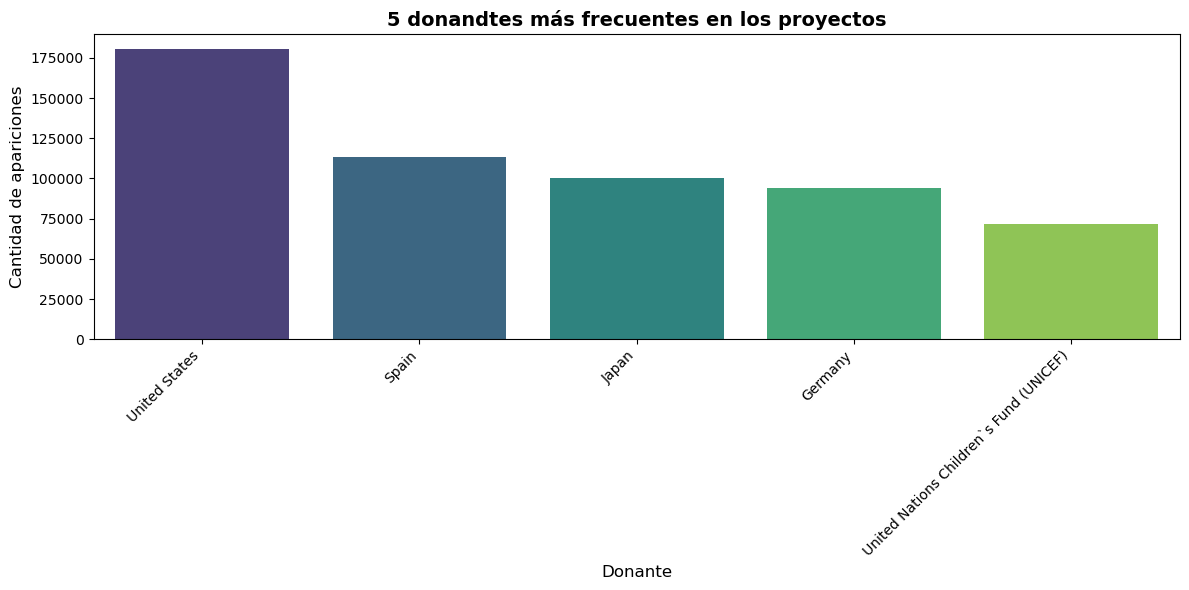

In [82]:
donor_counts = (
    data["donor"]
    .value_counts(sort=True).head(5)
)


df_counts = donor_counts.to_pandas()


plt.figure(figsize=(12, 6))
sns.barplot(data=df_counts, x='donor', y='count', palette='viridis')
plt.title('5 donandtes más frecuentes en los proyectos', fontsize=14, fontweight='bold')
plt.xlabel('Donante', fontsize=12)
plt.ylabel('Cantidad de apariciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [83]:
import polars.selectors as cs

data = data.with_columns(
    cs.numeric().exclude("year", "aiddata_id").clip(lower_bound=0)
)

In [84]:
data.describe()

statistic,aiddata_id,year,donor,recipient,title,short_description,long_description,aiddata_activity_codes,coalesced_purpose_code,commitment_amount_usd_constant,sdg_commitment_amount_usd_constant,goal_1,goal_2,goal_3,goal_4,goal_5,goal_6,goal_7,goal_8,goal_9,goal_10,goal_11,goal_12,goal_13,goal_14,goal_15,goal_16,goal_17
str,f64,f64,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""",1.252036e6,1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""",1.252036e6,"""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036""","""1252036"""
"""null_count""",0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",8.8870e10,2007.825313,null,null,null,null,null,null,null,1.6291e6,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",2.6936e11,3.721397,null,null,null,null,null,null,null,1.8099e7,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""",635824.0,2000.0,"""African Capacity Building Foun…","""Afghanistan""","""""","""""","""""","""""","""11000""",0.0,"""-1""","""-10561.5""","""-108798""","""-10214498""","""-1014824""","""-100090.7""","""-210898""","""-10469788""","""-0.2857143""","""-100.5""","""-11106.15""","""-100.5""","""-384831""","""0""","""-28373.5""","""-1055698""","""-0.7142857""","""-100.5"""
"""25%""",5.9812702e7,2005.0,null,null,null,null,null,null,null,16070.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",7.6971001e7,2008.0,null,null,null,null,null,null,null,74255.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",1.06961186e8,2011.0,null,null,null,null,null,null,null,354742.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""",9.0600e11,2013.0,"""World Trade Organization (WTO)…","""no value""","""„Petersberg Dialogue IV – Shap…","""„PETERSBERG DIALOGUE IV – SHAP…","""◦ Policy initiation on the exp…","""99820.01|92020.01""","""NA""",5.3367e9,"""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA""","""NA"""


In [85]:
from pathlib import Path
import polars as pl

FIN_CSV = Path("/home/aal1x/repo/Concurrente/datasets/financing_sdgs/FinancingtotheSDGsDataset_v1.0.csv")
if not FIN_CSV.is_file():
    FIN_CSV = Path.cwd() / "datasets" / "financing_sdgs" / "FinancingtotheSDGsDataset_v1.0.csv"
if not FIN_CSV.is_file():
    raise FileNotFoundError(f"No está el CSV: {FIN_CSV}. Corre: python download_datasets.py")

print("Leyendo", FIN_CSV)
data = pl.read_csv(FIN_CSV, infer_schema_length=None)

goal_cols = [f"goal_{i}" for i in range(1, 18)]
money_as_text = goal_cols + ["sdg_commitment_amount_usd_constant"]

data_clean = data.with_columns(
    pl.col("aiddata_id").cast(pl.Int64, strict=False),
    *[pl.col(c).cast(pl.Float64, strict=False).alias(c) for c in money_as_text],
)

data_clean = data_clean.with_columns(
    (pl.col("commitment_amount_usd_constant") < 0).alias("is_decommitment"),
    pl.sum_horizontal([(pl.col(c) < 0).cast(pl.UInt8) for c in goal_cols]).alias(
        "n_negative_sdg_cells"
    ),
)

non_country = r"(?i)regional|unspecified|bilateral|no value|multi-country|unallocated"
fin_country_year = (
    data_clean.with_columns(
        pl.col("recipient").str.to_lowercase().str.strip_chars().alias("recipient_key")
    )
    .filter(~pl.col("recipient_key").str.contains(non_country))
    .group_by(["recipient", "recipient_key", "year"])
    .agg(
        pl.len().alias("n_projects"),
        pl.col("donor").n_unique().alias("n_donors"),
        pl.col("commitment_amount_usd_constant").sum().alias("usd_total"),
        pl.col("goal_17").sum().alias("usd_ods17"),
        pl.col("goal_1").sum().alias("usd_ods1"),
        (pl.col("goal_17") > 0).sum().alias("n_projects_ods17"),
    )
    .sort(["recipient", "year"])
)

n = data_clean.height
n_decommit = data_clean.select(pl.col("is_decommitment").sum()).item()
n_neg_sdg = data_clean.select((pl.col("n_negative_sdg_cells") > 0).sum()).item()
print("Filas:", f"{n:,}")
print(f"Decommitments: {n_decommit:,} ({100 * n_decommit / n:.3f}%)")
print(f"Filas con goal_* negativo: {n_neg_sdg:,} ({100 * n_neg_sdg / n:.3f}%)")
print("Claves país-año:", f"{fin_country_year.height:,}")
print(data_clean.select(["aiddata_id", "commitment_amount_usd_constant"] + money_as_text).schema)
print(fin_country_year.head(5))

Leyendo /home/aal1x/repo/Concurrente/datasets/financing_sdgs/FinancingtotheSDGsDataset_v1.0.csv
Filas: 1,252,036
Decommitments: 869 (0.069%)
Filas con goal_* negativo: 713 (0.057%)
Claves país-año: 2,311
Schema({'aiddata_id': Int64, 'commitment_amount_usd_constant': Float64, 'goal_1': Float64, 'goal_2': Float64, 'goal_3': Float64, 'goal_4': Float64, 'goal_5': Float64, 'goal_6': Float64, 'goal_7': Float64, 'goal_8': Float64, 'goal_9': Float64, 'goal_10': Float64, 'goal_11': Float64, 'goal_12': Float64, 'goal_13': Float64, 'goal_14': Float64, 'goal_15': Float64, 'goal_16': Float64, 'goal_17': Float64, 'sdg_commitment_amount_usd_constant': Float64})
shape: (5, 9)
┌────────────┬────────────┬──────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ recipient  ┆ recipient_ ┆ year ┆ n_projects ┆ … ┆ usd_total  ┆ usd_ods17 ┆ usd_ods1  ┆ n_project │
│ ---        ┆ key        ┆ ---  ┆ ---        ┆   ┆ ---        ┆ ---       ┆ ---       ┆ s_ods17   │
│ str        ┆ ---        ┆ 

In [86]:
print("data_clean:", data_clean.shape)
print("fin_country_year:", fin_country_year.shape)

data_clean: (1252036, 30)
fin_country_year: (2311, 9)


In [87]:
print(fin_country_year.filter(pl.col("recipient_key").str.contains("peru")).head(8))
print(fin_country_year.describe())

shape: (8, 9)
┌───────────┬─────────────┬──────┬────────────┬───┬────────────┬───────────┬──────────┬────────────┐
│ recipient ┆ recipient_k ┆ year ┆ n_projects ┆ … ┆ usd_total  ┆ usd_ods17 ┆ usd_ods1 ┆ n_projects │
│ ---       ┆ ey          ┆ ---  ┆ ---        ┆   ┆ ---        ┆ ---       ┆ ---      ┆ _ods17     │
│ str       ┆ ---         ┆ i64  ┆ u32        ┆   ┆ f64        ┆ f64       ┆ f64      ┆ ---        │
│           ┆ str         ┆      ┆            ┆   ┆            ┆           ┆          ┆ u32        │
╞═══════════╪═════════════╪══════╪════════════╪═══╪════════════╪═══════════╪══════════╪════════════╡
│ Peru      ┆ peru        ┆ 2000 ┆ 515        ┆ … ┆ 1.0743e9   ┆ 5.5075e7  ┆ 2.3305e7 ┆ 38         │
│ Peru      ┆ peru        ┆ 2001 ┆ 746        ┆ … ┆ 4.80572049 ┆ 6.7507e6  ┆ 6.1237e6 ┆ 52         │
│           ┆             ┆      ┆            ┆   ┆ e8         ┆           ┆          ┆            │
│ Peru      ┆ peru        ┆ 2002 ┆ 699        ┆ … ┆ 6.40957606 ┆ 2.4991e7  ┆ 

## Limpieza de la tabla unida (sin modelar)

Todo vive en este notebook. Una fila = un proyecto PPD evaluado. Banco y Financing se pegan por **ISO3 + año de inicio**.

- Duración: el PPD viene en **días**. Queda `duration_years`. Si el valor es 1–40, la unidad no se sabe → nulo.
- Compromiso ≤ 0 → nulo. Agregados tipo `World` no son país.
- Contexto BM/Financing solo con datos **anteriores** al inicio.
- `fila_ok` = país real + año 1990–2017.


In [88]:
from pathlib import Path
import re
import unicodedata
import polars as pl

ROOT = Path.cwd()
if not (ROOT / "datasets" / "ppd").exists():
    ROOT = Path("/home/aal1x/repo/Concurrente")

PPD_CSV = ROOT / "datasets" / "ppd" / "PPD2_Jan_21_2022.csv"
WB_CSV = ROOT / "datasets" / "worldbank_sdg" / "SDGData.csv"
WB_META = ROOT / "datasets" / "worldbank_sdg" / "SDGCountry.csv"
FIN_CSV = ROOT / "datasets" / "financing_sdgs" / "FinancingtotheSDGsDataset_v1.0.csv"
for p in (PPD_CSV, WB_CSV, WB_META, FIN_CSV):
    if not p.is_file():
        raise FileNotFoundError(f"Falta {p}. Corre: python download_datasets.py")

PPD_COLS = [
    "project_id", "donor", "countryname_WB", "country_code_WB", "start_date",
    "startyear", "wb_startyear", "sector_code", "sector_description",
    "purpose_code", "purpose_description", "project_duration",
    "wb_netcommitment", "six_overall_rating",
]
WB_CORE = {
    "NY.GDP.PCAP.PP.KD": "gdp_pc_ppp",
    "NY.GDP.PCAP.CD": "gdp_pc",
    "NY.GDP.PCAP.KD.ZG": "gdp_pc_growth",
    "EG.ELC.ACCS.ZS": "elec_access",
    "SH.DYN.MORT": "child_mort",
    "SL.UEM.TOTL.ZS": "unemp",
    "SP.URB.TOTL.IN.ZS": "urban_pct",
    "IT.NET.USER.ZS": "internet_pct",
}
WB_SPARSE = {"SI.POV.DDAY": "poverty", "SE.ADT.LITR.ZS": "literacy"}
WB_KEEP = {**WB_CORE, **WB_SPARSE}
LOOKBACK_CORE, LOOKBACK_SPARSE = 5, 10
NON_COUNTRY = re.compile(
    r"(?i)regional|unspecified|bilateral|no value|multi-country|unallocated|global|madct|ex-yugoslav"
)
ALIASES = {
    "viet nam": "VNM", "vietnam": "VNM", "bosnia herzegovina": "BIH",
    "cape verde": "CPV", "cabo verde": "CPV", "turkey": "TUR", "turkiye": "TUR",
    "venezuela": "VEN", "venezuela rb": "VEN", "yemen": "YEM", "yemen rep": "YEM",
    "egypt": "EGY", "egypt arab rep": "EGY", "gambia": "GMB", "the gambia": "GMB",
    "congo": "COG", "congo rep": "COG", "democratic republic of the congo": "COD",
    "congo dem rep": "COD", "zaire": "COD", "korea": "KOR", "korea rep": "KOR",
    "korea democratic republic of": "PRK", "laos": "LAO", "lao pdr": "LAO",
    "ivory coast": "CIV", "cote d ivoire": "CIV", "cote divoire": "CIV",
    "swaziland": "SWZ", "eswatini": "SWZ", "macedonia": "MKD", "macedonia fyr": "MKD",
    "slovakia": "SVK", "kyrgyzstan": "KGZ", "moldova": "MDA", "russia": "RUS",
    "syria": "SYR", "tanzania": "TZA", "iran": "IRN", "west bank and gaza": "PSE",
    "palestine": "PSE", "palestinian adm areas": "PSE",
    "micronesia federated states of": "FSM", "st lucia": "LCA",
    "st vincent and grenadines": "VCT", "st vincent and the grenadines": "VCT",
    "myanmar": "MMR", "brunei": "BRN", "bahamas": "BHS", "east timor": "TLS",
    "timor leste": "TLS", "sao tome and principe": "STP",
}


def norm_name(s):
    if s is None:
        return ""
    text = unicodedata.normalize("NFKD", str(s))
    text = "".join(c for c in text if not unicodedata.combining(c))
    text = text.lower().replace("&", " and ")
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def map_iso(name, lookup):
    n = norm_name(name)
    if not n or NON_COUNTRY.search(n):
        return None
    return lookup.get(n)


wb_countries = pl.read_csv(WB_META, infer_schema_length=None)
lookup = {}
for row in wb_countries.iter_rows(named=True):
    iso = row["Country Code"]
    if not iso:
        continue
    for key in ("Short Name", "Table Name", "Long Name"):
        n = norm_name(row.get(key))
        if n:
            lookup[n] = iso
lookup.update(ALIASES)

aggregates = set(
    wb_countries.filter(
        pl.col("Region").is_null() | (pl.col("Region").str.strip_chars() == "")
    ).get_column("Country Code").drop_nulls().to_list()
)
print("ISO3 listos. Agregados WB (no país):", len(aggregates))


ISO3 listos. Agregados WB (no país): 44


In [89]:
# PPD: solo columnas usables al inicio + nota + año
ppd_raw = pl.read_csv(
    PPD_CSV,
    columns=PPD_COLS,
    schema_overrides={c: pl.Utf8 for c in PPD_COLS},
    infer_schema_length=0,
)
ppd = ppd_raw.with_columns(
    pl.col("countryname_WB").str.replace_all(r"[\u00a0\u2007\u202f]", " ").str.strip_chars(),
    pl.col("country_code_WB").str.strip_chars(),
    pl.col("donor").str.strip_chars(),
    pl.col("six_overall_rating").cast(pl.Float64, strict=False).alias("rating"),
    pl.col("startyear").cast(pl.Int64, strict=False),
    pl.col("wb_startyear").cast(pl.Int64, strict=False),
    pl.col("project_duration").cast(pl.Float64, strict=False),
    pl.col("wb_netcommitment").cast(pl.Float64, strict=False),
    pl.coalesce([
        pl.col("start_date").str.to_date("%m/%d/%Y", strict=False),
        pl.col("start_date").str.to_date("%-m/%-d/%Y", strict=False),
        pl.col("start_date").str.to_date("%-m/%-d/%y", strict=False),
        pl.col("start_date").str.to_date("%Y-%m-%d", strict=False),
    ]).dt.year().alias("year_from_date"),
)
wb_year_ok = pl.when((pl.col("wb_startyear") >= 1950) & (pl.col("wb_startyear") <= 2020)).then(pl.col("wb_startyear"))
ppd = ppd.with_columns(pl.coalesce(["startyear", "year_from_date", wb_year_ok]).alias("start_year"))
ppd = ppd.with_columns(
    pl.when((pl.col("start_year") < 1950) | (pl.col("start_year") > 2020)).then(None).otherwise(pl.col("start_year")).alias("start_year"),
    (pl.col("rating") >= 4).cast(pl.Int8).alias("success"),
)
iso_from_name = {
    row["countryname_WB"]: map_iso(row["countryname_WB"], lookup)
    for row in ppd.select("countryname_WB").unique().iter_rows(named=True)
}
ppd = ppd.with_columns(pl.col("countryname_WB").replace_strict(iso_from_name, default=None).alias("iso_from_name"))
ppd = ppd.with_columns(
    pl.when(pl.col("country_code_WB").str.contains(r"^[A-Z]{3}$"))
    .then(pl.col("country_code_WB"))
    .otherwise(pl.col("iso_from_name"))
    .alias("iso3")
)
known_donors = ppd.group_by("donor").len().filter(pl.col("len") >= 10).get_column("donor").to_list()
ppd = ppd.filter(pl.col("donor").is_in(known_donors)).unique(subset=["project_id"], keep="first")
ppd = ppd.filter(pl.col("rating").is_not_null() & pl.col("start_year").is_not_null())
ppd = ppd.with_columns(
    pl.col("iso3").is_null().alias("is_regional"),
    ((pl.col("start_year") >= 2000) & (pl.col("start_year") <= 2013)).alias("in_financing_window"),
)
print("PPD con nota y año:", ppd.height, "| éxito:", round(100 * ppd.select(pl.col("success").mean()).item(), 1), "%")


PPD con nota y año: 20623 | éxito: 73.7 %


In [90]:
# Banco Mundial: panel país-año (solo países reales, no agregados WLD/SAS…)
real = wb_countries.filter(pl.col("Region").is_not_null() & (pl.col("Region").str.strip_chars() != ""))
wb_raw = pl.read_csv(WB_CSV, infer_schema_length=None).filter(
    pl.col("Country Code").is_in(real.get_column("Country Code").to_list())
)
year_cols = [c for c in wb_raw.columns if str(c).isdigit()]
wb_long = (
    wb_raw.filter(pl.col("Indicator Code").is_in(list(WB_KEEP)))
    .select(["Country Code", "Indicator Code", *year_cols])
    .unpivot(index=["Country Code", "Indicator Code"], on=year_cols, variable_name="year", value_name="value")
    .with_columns(
        pl.col("year").cast(pl.Int32),
        pl.col("value").cast(pl.Float64, strict=False),
        pl.col("Indicator Code").replace_strict(WB_KEEP).alias("feat"),
    )
    .filter(pl.col("value").is_not_null())
    .rename({"Country Code": "iso3"})
)
wb = wb_long.pivot(on="feat", index=["iso3", "year"], values="value").sort(["iso3", "year"])
feat_names = list(WB_KEEP.values())
for feat in feat_names:
    if feat not in wb.columns:
        wb = wb.with_columns(pl.lit(None).cast(pl.Float64).alias(feat))
    wb = wb.with_columns(
        pl.when(pl.col(feat).is_not_null()).then(pl.col("year")).otherwise(None).cast(pl.Int32).alias(f"{feat}_year")
    )
years = pl.DataFrame({"year": list(range(1960, 2021))}, schema={"year": pl.Int32})
wb = (
    wb.select("iso3").unique().join(years, how="cross")
    .join(wb, on=["iso3", "year"], how="left")
    .sort(["iso3", "year"])
    .with_columns(pl.col(feat_names + [f"{f}_year" for f in feat_names]).forward_fill().over("iso3"))
)
meta = real.select(
    pl.col("Country Code").alias("iso3"),
    pl.col("Region").str.strip_chars().alias("wb_region"),
    pl.col("Income Group").str.strip_chars().alias("wb_income"),
).with_columns(
    pl.when(pl.col("wb_region") == "").then(None).otherwise(pl.col("wb_region")).alias("wb_region"),
    pl.when(pl.col("wb_income") == "").then(None).otherwise(pl.col("wb_income")).alias("wb_income"),
)
wb = wb.join(meta, on="iso3", how="left")
print("WB país-año:", wb.shape)


WB país-año: (13237, 24)


In [91]:
# Financing: agregado país × año por ISO3 (no por nombre)
fin_raw = pl.read_csv(FIN_CSV, infer_schema_length=None)
goal_cols = [f"goal_{i}" for i in range(1, 18)]
fin_raw = fin_raw.with_columns(
    *[pl.col(c).cast(pl.Float64, strict=False) for c in goal_cols + ["sdg_commitment_amount_usd_constant"]],
    (pl.col("commitment_amount_usd_constant") < 0).alias("is_decommitment"),
)
rec_map = {rec: map_iso(rec, lookup) for rec in fin_raw.select("recipient").unique().to_series()}
fin_raw = fin_raw.with_columns(pl.col("recipient").replace_strict(rec_map, default=None).alias("iso3"))
fin_panel = (
    fin_raw.filter(pl.col("iso3").is_not_null())
    .group_by(["iso3", "year"])
    .agg(
        pl.len().alias("n_aid_projects"),
        pl.col("donor").n_unique().alias("n_donors"),
        pl.col("commitment_amount_usd_constant").sum().alias("usd_total_net"),
        pl.col("commitment_amount_usd_constant").filter(pl.col("commitment_amount_usd_constant") > 0).sum().alias("usd_total_gross"),
        pl.col("goal_17").sum().alias("usd_ods17"),
        (pl.col("goal_17") > 0).sum().alias("n_projects_ods17"),
        pl.col("is_decommitment").sum().alias("n_decommitments"),
    )
    .sort(["iso3", "year"])
)
fin_feats = ["n_aid_projects", "n_donors", "usd_total_net", "usd_total_gross", "usd_ods17", "n_projects_ods17", "n_decommitments"]
fin_years = pl.DataFrame({"year": list(range(2000, 2014))})
fin = (
    fin_panel.select("iso3").unique().join(fin_years, how="cross")
    .join(fin_panel, on=["iso3", "year"], how="left")
    .sort(["iso3", "year"])
    .with_columns(
        pl.col("year").cast(pl.Int32),
        pl.when(pl.col("n_aid_projects").is_not_null()).then(pl.col("year")).otherwise(None).alias("fin_year"),
    )
    .with_columns(pl.col(fin_feats + ["fin_year"]).forward_fill().over("iso3"))
)
print("Financing país-año:", fin_panel.height, "| recipients sin ISO3:", sum(v is None for v in rec_map.values()))


Financing país-año: 2137 | recipients sin ISO3: 41


In [92]:
# Join ISO3+año (solo pasado) y sanitizar
ppd = ppd.with_columns(pl.col("start_year").cast(pl.Int32))
model_df = ppd.join(wb, left_on=["iso3", "start_year"], right_on=["iso3", "year"], how="left")

for src, names in ((WB_CORE, WB_CORE), (WB_SPARSE, WB_SPARSE)):
    look = LOOKBACK_CORE if src is WB_CORE else LOOKBACK_SPARSE
    exprs = []
    for name in names.values():
        ycol = f"{name}_year"
        if ycol not in model_df.columns:
            continue
        stale = (pl.col("start_year") - pl.col(ycol)) > look
        exprs += [
            pl.when(stale).then(None).otherwise(pl.col(name)).alias(name),
            pl.when(stale).then(None).otherwise(pl.col(ycol)).alias(ycol),
        ]
    if exprs:
        model_df = model_df.with_columns(exprs)

model_df = model_df.with_columns(
    pl.when(pl.col("start_year") < 2000).then(None)
    .when(pl.col("start_year") > 2013).then(pl.lit(2013))
    .otherwise(pl.col("start_year")).cast(pl.Int32).alias("fin_join_year")
)
model_df = model_df.join(fin, left_on=["iso3", "fin_join_year"], right_on=["iso3", "year"], how="left")
for c in fin_feats + ["fin_year"]:
    if c in model_df.columns:
        model_df = model_df.with_columns(
            pl.when(pl.col("start_year") < 2000).then(None).otherwise(pl.col(c)).alias(c)
        )

# textos vacíos → nulo
str_cols = [c for c, t in model_df.schema.items() if t == pl.String]
model_df = model_df.with_columns([
    pl.when(pl.col(c).str.strip_chars() == "").then(None).otherwise(pl.col(c).str.strip_chars()).alias(c)
    for c in str_cols
])
model_df = model_df.with_columns(
    pl.when(pl.col("iso3").is_in(list(aggregates))).then(None).otherwise(pl.col("iso3")).alias("iso3")
)
model_df = model_df.with_columns(pl.col("iso3").is_null().alias("is_regional"))

days = pl.col("project_duration")
model_df = model_df.with_columns(
    pl.when(days.is_null() | (days <= 0)).then(None)
    .when(days > 40).then(days / 365.25)
    .otherwise(None)
    .alias("duration_years")
)
model_df = model_df.with_columns(
    pl.when(pl.col("duration_years") > 25).then(None).otherwise(pl.col("duration_years")).alias("duration_years"),
    pl.when(pl.col("wb_netcommitment") > 0).then(pl.col("wb_netcommitment")).otherwise(None).alias("commitment_usd"),
)
for c in ["elec_access", "unemp", "urban_pct", "internet_pct", "poverty", "literacy"]:
    model_df = model_df.with_columns(pl.when((pl.col(c) < 0) | (pl.col(c) > 100)).then(None).otherwise(pl.col(c)).alias(c))
for c in ["gdp_pc", "gdp_pc_ppp", "child_mort"]:
    model_df = model_df.with_columns(pl.when(pl.col(c) <= 0).then(None).otherwise(pl.col(c)).alias(c))

model_df = model_df.filter(pl.col("rating").is_not_null() & pl.col("start_year").is_not_null())
model_df = model_df.with_columns(
    (pl.col("rating") >= 4).cast(pl.Int8).alias("success"),
    pl.col("gdp_pc").is_not_null().alias("has_wb_context"),
    pl.col("usd_total_net").is_not_null().alias("has_financing"),
    (
        pl.col("iso3").is_not_null()
        & (pl.col("start_year") >= 1990)
        & (pl.col("start_year") <= 2017)
    ).alias("fila_ok"),
)

keep = [
    "project_id", "donor", "iso3", "countryname_WB", "start_year", "is_regional", "fila_ok",
    "in_financing_window", "has_wb_context", "has_financing", "sector_code", "sector_description",
    "purpose_code", "duration_years", "commitment_usd", "wb_region", "wb_income",
    *WB_KEEP.values(), "n_aid_projects", "n_donors", "usd_total_net", "usd_total_gross",
    "usd_ods17", "n_projects_ods17", "n_decommitments", "fin_year", "rating", "success",
]
keep += [c for c in model_df.columns if c.endswith("_year") and c not in keep]
model_df = model_df.select([c for c in keep if c in model_df.columns]).sort(["start_year", "iso3", "project_id"])

out = ROOT / "datasets" / "parquet" / "model_table.parquet"
out.parent.mkdir(parents=True, exist_ok=True)
model_df.write_parquet(out)
print("Tabla:", model_df.shape, "| fila_ok:", model_df.select(pl.col("fila_ok").sum()).item())
print("Guardado:", out)
model_df.head(5)


Tabla: (20623, 48) | fila_ok: 13915
Guardado: /home/aal1x/repo/Concurrente/datasets/parquet/model_table.parquet


project_id,donor,iso3,countryname_WB,start_year,is_regional,fila_ok,in_financing_window,has_wb_context,has_financing,sector_code,sector_description,purpose_code,duration_years,commitment_usd,wb_region,wb_income,gdp_pc_ppp,gdp_pc,gdp_pc_growth,elec_access,child_mort,unemp,urban_pct,internet_pct,poverty,literacy,n_aid_projects,n_donors,usd_total_net,usd_total_gross,usd_ods17,n_projects_ods17,n_decommitments,fin_year,rating,success,gdp_pc_ppp_year,gdp_pc_year,gdp_pc_growth_year,elec_access_year,child_mort_year,unemp_year,urban_pct_year,internet_pct_year,poverty_year,literacy_year,fin_join_year
str,str,str,str,i32,bool,bool,bool,bool,bool,str,str,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,f64,f64,f64,u32,u32,i64,f64,i8,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
"""17889""","""WB""","""NIC""","""Nicaragua""",1956,false,false,false,false,false,"""210""","""Transport & Storage""","""21040""",23.104723,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,5.0,1,null,null,null,null,null,null,null,null,null,null,null
"""15088""","""WB""","""IND""","""India""",1958,false,false,false,false,false,"""210""","""Transport & Storage""","""21040""",8.013689,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,5.0,1,null,null,null,null,null,null,null,null,null,null,null
"""18065""","""WB""","""PAK""","""Pakistan""",1959,false,false,false,false,false,"""230""","""Energy""","""23020""",19.879535,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,5.0,1,null,null,null,null,null,null,null,null,null,null,null
"""13402""","""WB""","""CRI""","""Costa Rica""",1961,false,false,false,false,false,"""210""","""Transport & Storage""","""21020""",6.71321,null,"""Latin America & Caribbean""","""Upper middle income""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,5.0,1,null,null,null,null,null,null,null,null,null,null,null
"""13403""","""WB""","""CRI""","""Costa Rica""",1961,false,false,false,false,false,"""230""","""Energy""","""23000""",3.403149,null,"""Latin America & Caribbean""","""Upper middle income""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,5.0,1,null,null,null,null,null,null,null,null,null,null,null


In [95]:
# Evidencia de la data (Figura 4) — corre esta celda y captura la tabla
from pathlib import Path
import polars as pl

src = Path("datasets/parquet/model_table.parquet")
if not src.is_file():
    src = Path("/home/aal1x/repo/Concurrente/datasets/parquet/model_table.parquet")
tabla = pl.read_parquet(src)

print(
    f"model_table.parquet  |  {tabla.height} filas × {tabla.width} cols  |  "
    f"fila_ok: {tabla.select(pl.col('fila_ok').sum()).item()}"
)

evidencia = (
    tabla.filter(
        pl.col("fila_ok")
        & pl.col("usd_ods17").is_not_null()
        & pl.col("gdp_pc").is_not_null()
    )
    .select(
        "project_id", "donor", "iso3", "start_year",
        "duration_years", "gdp_pc", "usd_ods17", "success", "fila_ok",
    )
    .head(8)
    .with_columns(
        pl.col("duration_years").round(2),
        pl.col("gdp_pc").round(1),
        pl.col("usd_ods17").round(0),
    )
)
evidencia.to_pandas()


model_table.parquet  |  20623 filas × 48 cols  |  fila_ok: 13915


project_id,donor,iso3,start_year,duration_years,gdp_pc,usd_ods17,success,fila_ok
11046,WB,AGO,2000,3.67,556.8,4748970.0,1,True
11088,WB,ALB,2000,6.74,1126.7,8374873.0,0,True
11089,WB,ALB,2000,5.08,1126.7,8374873.0,1,True
11090,WB,ALB,2000,4.41,1126.7,8374873.0,1,True
11091,WB,ALB,2000,4.02,1126.7,8374873.0,1,True
11092,WB,ALB,2000,5.53,1126.7,8374873.0,0,True
11093,WB,ALB,2000,4.47,1126.7,8374873.0,1,True
2993,DFID,ALB,2000,7.33,1126.7,8374873.0,1,True


In [93]:
import polars as pl

print("Rangos después de limpiar (no deberían verse días ni % > 100)")
print(model_df.select(["duration_years", "commitment_usd", "gdp_pc", "elec_access", "rating"]).describe())

print("\nNulos por columna")
print(model_df.null_count())

ok = model_df.filter(pl.col("fila_ok"))
print(f"\nfila_ok: {ok.height:,} de {model_df.height:,}")
print("Regionales / sin país:", model_df.select(pl.col("is_regional").sum()).item())
print(
    ok.select(["project_id", "donor", "iso3", "start_year", "duration_years", "gdp_pc", "usd_ods17", "success"]).head(8)
)


Rangos después de limpiar (no deberían verse días ni % > 100)
shape: (9, 6)
┌────────────┬────────────────┬────────────────┬──────────────┬─────────────┬───────────┐
│ statistic  ┆ duration_years ┆ commitment_usd ┆ gdp_pc       ┆ elec_access ┆ rating    │
│ ---        ┆ ---            ┆ ---            ┆ ---          ┆ ---         ┆ ---       │
│ str        ┆ f64            ┆ f64            ┆ f64          ┆ f64         ┆ f64       │
╞════════════╪════════════════╪════════════════╪══════════════╪═════════════╪═══════════╡
│ count      ┆ 18720.0        ┆ 8820.0         ┆ 13345.0      ┆ 11500.0     ┆ 20623.0   │
│ null_count ┆ 1903.0         ┆ 11803.0        ┆ 7278.0       ┆ 9123.0      ┆ 0.0       │
│ mean       ┆ 6.108512       ┆ 7.3327e7       ┆ 1767.048955  ┆ 61.963461   ┆ 4.203348  │
│ std        ┆ 2.886101       ┆ 1.2715e8       ┆ 2285.011875  ┆ 34.150719   ┆ 1.166912  │
│ min        ┆ 0.112252       ┆ 1.0            ┆ 65.510583    ┆ 0.533899    ┆ 1.0       │
│ 25%        ┆ 4.279261 

In [94]:
# Control de calidad: la tabla ya no debe tener estas suciedades.
checks = {
    "project_id duplicado": model_df.filter(pl.col("project_id").is_duplicated()).height,
    "rating fuera de 1–6": model_df.filter((pl.col("rating") < 1) | (pl.col("rating") > 6)).height,
    "duración <= 0 o > 25": model_df.filter(
        pl.col("duration_years").is_not_null()
        & ((pl.col("duration_years") <= 0) | (pl.col("duration_years") > 25))
    ).height,
    "compromiso <= 0": model_df.filter(
        pl.col("commitment_usd").is_not_null() & (pl.col("commitment_usd") <= 0)
    ).height,
    "% fuera de 0–100": model_df.filter(
        ((pl.col("elec_access") < 0) | (pl.col("elec_access") > 100))
        | ((pl.col("urban_pct") < 0) | (pl.col("urban_pct") > 100))
    ).height,
    "agregados WB como país": model_df.filter(
        pl.col("iso3").is_in(["WLD", "SAS", "EAS", "ECS", "MEA"])
    ).height,
    "textos vacíos": sum(
        model_df.select((pl.col(c) == "").sum()).item()
        for c, t in model_df.schema.items()
        if t == pl.String
    ),
}
for k, v in checks.items():
    print(("OK " if v == 0 else "FALLO "), k, "=", v)


OK  project_id duplicado = 0
OK  rating fuera de 1–6 = 0
OK  duración <= 0 o > 25 = 0
OK  compromiso <= 0 = 0
OK  % fuera de 0–100 = 0
OK  agregados WB como país = 0
OK  textos vacíos = 0


Tabla limpia: `datasets/parquet/model_table.parquet` (también queda en `model_df`).

Filtrar `fila_ok` cuando armen el modelo. Los nulos que quedan son huecos reales: no rellenar con 0.
